# Predicciones
Dentro de este archivo y a lo largo del mismo, se exploraran diversas tecnicas y algoritmos de prediccion con el fin de poder estimar valores basados en nuestros datos actuales, para ello se intentara resolver las siguientes preguntas:

1. ¿Es posible predecir la popularidad de una canción usando únicamente sus características musicales?

2. ¿Qué variables tienen mayor importancia en el modelo predictivo?

3. ¿Qué algoritmo ofrece mejor desempeño para estimar la popularidad?

4. ¿Se puede clasificar una canción como "éxito" o "no éxito" utilizando aprendizaje automático?

5. ¿Puede un modelo de machine learning predecir el éxito comercial de una canción antes de su lanzamiento?

<hr />


In [20]:
import pandas as pd

caracteristicas = pd.read_csv('../dataset/main_dataset.csv', usecols=['popularity','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','valence','tempo','duration_ms','time_signature','liveness', 'album_type'])
caracteristicas.head()
caracFinales = pd.DataFrame()

## Transformaciones

Con el fin de realizar mejores predicciones, se realizara una serie de diferentes transformaciones a las variables del dataset con el fin de simplificar o generalizar algunas caracteristicas de las canciones.

### Cambios
1. **popularity**
    * Primero se observaran las popularidades de las diversas canciones y con respecto, a ello. se realizara el tratamiento de outliners. Asi mismo, se categorizara la variable con el fin de que sea mas sencillo realizar una prediccion sobre ella, aquellas canciones por encima de un 60 de popularidad (popularity >= 60) se denominara como cancion popular o exito, en caso contrario (popularity < 60) se le catalogara como fracaso.

2. **acousticness**
    * Para esta variable, tambien se realizara una categorizacion puesto que al ser una probabilidad, los diversos valores solo meteran ruido en la informacion. Por esto mismo, a aquellas canciones que un acousticness mayor a 60 (acousticness >= 60) se les asignara el valor 1 (acustica), de otra forma (acousticness < 60), se les catalogara como 0 (electrica/sintetica)

3. **album_type**
    * Se categorizara la variable como 1 o 0, con el fin de usar numeros

4. **instrumentalness**
    * Para aquellos valores mayores a 0.6 (instrumentalness >= 0.6) se tomaran como 1 (canciones puramente intrsumentales), de otra forma, se asignara 0 (canciones no instrumentales)

5. **tempo**
    * Se le realizara una estandarizacion

6. **duracion**
    * Se le realizara una estandarizacion

7. **time_signature**
    * Se tranformaran a enteros


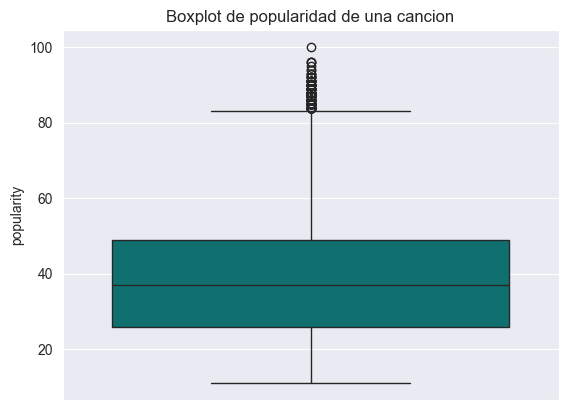

=============== valores >= 50 ===============
Cantidad de valores mayores de  50: 47748
Porcentaje de valores mayores de 50: 24.0%


,popularity
0,0
1,1
2,0
3,0
4,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


caracteristicas = caracteristicas[
    caracteristicas['popularity'] > 10]

popularidades = caracteristicas['popularity']


sns.set_style('darkgrid')
sns.boxplot(popularidades, color='teal')
plt.title('Boxplot de popularidad de una cancion')
plt.show()


resumen5 = {
    'num': np.where(popularidades >= 50, 1, 0).sum(),
    'prc': np.round(np.where(popularidades >= 50, 1, 0).mean(),2)*100
}
print('='*15, 'valores >= 50','='*15)
print(f'Cantidad de valores mayores de  50: {resumen5["num"]}')
print(f'Porcentaje de valores mayores de 50: {resumen5["prc"]}%')

caracFinales['popularity'] = np.where(caracteristicas['popularity'] >= 50, 1,0)
caracFinales.heah()


Se eliminaron del conjunto de datos aquellas canciones con una popularidad inferior a 10 puntos. Esta decisión se fundamenta en que una baja popularidad no necesariamente refleja una falta de calidad o de características asociadas al éxito comercial. En muchos casos, canciones con atributos similares a los de temas exitosos pueden no alcanzar una alta popularidad debido a factores externos, como estrategias de promoción, exposición mediática, tendencias del mercado o elementos aleatorios difíciles de cuantificar.

Con base en el análisis de la grafica del conjunto de datos, se estableció un umbral de popularidad de 50 puntos para clasificar una canción como un éxito. Inicialmente, se consideró utilizar un umbral de 60 puntos; sin embargo, esta elección generaba una distribución altamente desbalanceada, ya que únicamente alrededor del 7% de las observaciones eran clasificadas como éxitos.

Al reducir el umbral a 50 puntos, la proporción de canciones catalogadas como éxitos aumenta aproximadamente al 17% del conjunto de datos. Aunque la distribución resultante continúa presentando cierto grado de desbalance, este nivel es considerablemente más manejable para el entrenamiento y evaluación de modelos de aprendizaje automático, permitiendo obtener resultados más robustos y representativos.

### Acousticness)


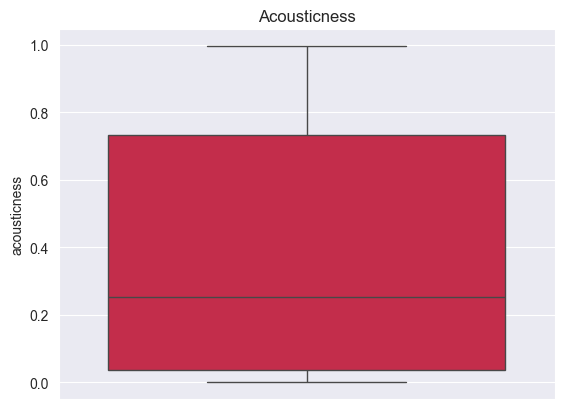

=============== valores >= .6 ===============
Cantidad de valores mayores o iguales a 0.6 (acousticness >= 0.6): 63181
Porcentaje de valores mayores o iguales a 0.6 (acousticness >= 0.6): 32.0%


In [ ]:

acustica = caracteristicas['acousticness']

sns.boxplot(acustica, color='crimson')
plt.title('Acousticness')
plt.show()

resumenAcous = {
    'num': np.where(acustica >= 0.6, 1, 0).sum(),
    'prc': np.round(np.where(acustica >= 0.6, 1, 0).mean(),2)*100
}
print('='*15, 'valores >= .6','='*15)
print(f'Cantidad de valores mayores o iguales a 0.6 (acousticness >= 0.6): {resumenAcous["num"]}')
print(f'Porcentaje de valores mayores o iguales a 0.6 (acousticness >= 0.6): {resumenAcous["prc"]}%')

caracFinales['acousticness'] = np.where(caracteristicas['acousticness'] >= 0.6)

